In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../data/telco_churn.csv')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Cell 2 — understand our target variable (what we're predicting)
print("Churn distribution:")
print(df['Churn'].value_counts())
print("\nAs percentages:")
print(df['Churn'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

As percentages:
Churn
No     73.5%
Yes    26.5%
Name: proportion, dtype: str


In [3]:
# Cell 3 — check for missing values and data types
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

# TotalCharges should be a number but it's stored as text — fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many became NaN after conversion
print("\nTotalCharges nulls after fix:", df['TotalCharges'].isnull().sum())

# Fill those nulls with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print("Fixed! No more nulls.")

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod       

C:\Users\Meghana\AppData\Local\Temp\ipykernel_23336\2333058533.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [4]:
# Cell 4 — fix the warning from previous cell (cleaner syntax)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Verify
print("Nulls remaining:", df['TotalCharges'].isnull().sum())
print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("\nDataset looks clean! Ready for EDA.")

Nulls remaining: 0
TotalCharges dtype: float64

Dataset looks clean! Ready for EDA.


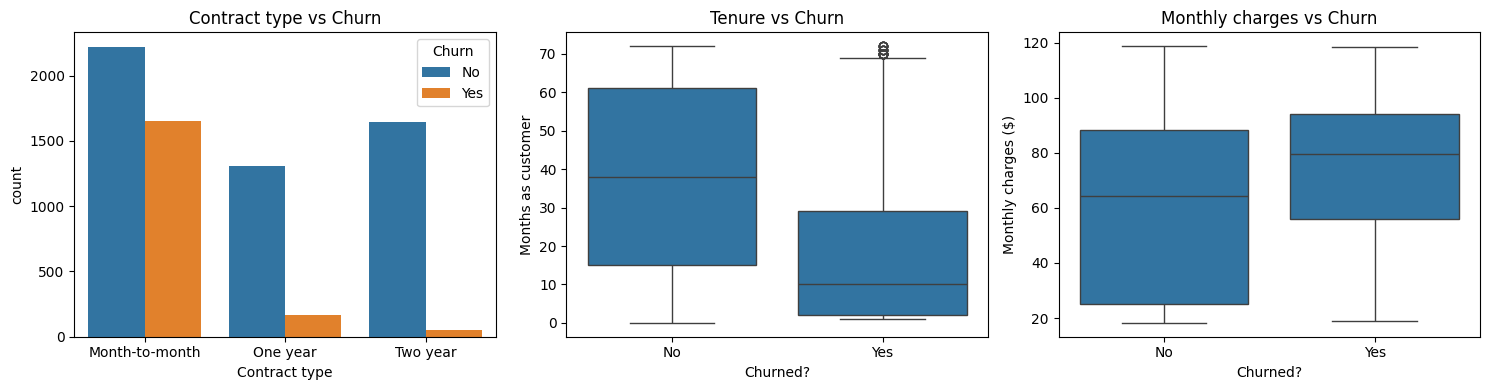

In [5]:
# Cell 5 — 3 key visualizations that tell the churn story
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chart 1: Contract type vs Churn
# Theory: month-to-month customers have no commitment = easier to leave
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0])
axes[0].set_title('Contract type vs Churn')
axes[0].set_xlabel('Contract type')

# Chart 2: Tenure vs Churn
# Theory: newer customers churn more — they haven't built loyalty yet
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1])
axes[1].set_title('Tenure vs Churn')
axes[1].set_xlabel('Churned?')
axes[1].set_ylabel('Months as customer')

# Chart 3: Monthly charges vs Churn
# Theory: expensive plans = more likely to shop around
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[2])
axes[2].set_title('Monthly charges vs Churn')
axes[2].set_xlabel('Churned?')
axes[2].set_ylabel('Monthly charges ($)')

plt.tight_layout()
plt.show()

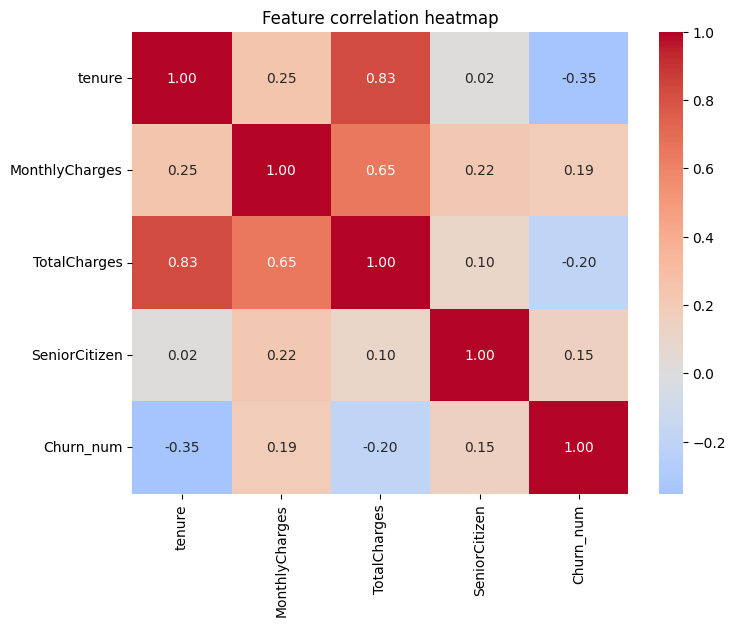

In [6]:
# Cell 6 — correlation heatmap
# Shows which numerical features relate to each other

# Create a copy with Churn as number for correlation
df_corr = df.copy()
df_corr['Churn_num'] = (df_corr['Churn'] == 'Yes').astype(int)

# Only numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_num']

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_corr[num_cols].corr(),
    annot=True,        # show numbers inside boxes
    fmt='.2f',         # 2 decimal places
    cmap='coolwarm',   # blue = negative, red = positive correlation
    center=0
)
plt.title('Feature correlation heatmap')
plt.show()

In [7]:
# Cell 7 — save our clean dataframe before we move to training
# We'll use this in our training script

df.to_csv('../data/telco_churn_clean.csv', index=False)
print("Clean data saved!")
print(f"Shape: {df.shape}")
print(f"Churn rate: {(df['Churn'] == 'Yes').mean():.1%}")

Clean data saved!
Shape: (7043, 21)
Churn rate: 26.5%
